# 🎓 A Nova Fronteira da IA Generativa: Modelos de Difusão
**Disciplina:** GENERATIVE AI & ADVANCED NETS  
**Curso:** Tecnólogo em Inteligência Artificial  

---

## 🎯 Objetivos de Aprendizagem

Ao final desta aula prática, você será capaz de:
1. **Compreender** por que os Modelos de Difusão superaram as limitações históricas das GANs em termos de estabilidade e diversidade de amostras.
2. **Explicar** a matemática intuitiva do processo de **Difusão Direta (*Forward Pass*)** e do processo de **Difusão Reversa (*Reverse Denoising Pass*)**.
3. **Identificar** o papel da rede **U-Net** e dos mecanismos de **Atenção Cruzada (*Cross-Attention*)** orientados pelo modelo **CLIP**.
4. **Diferenciar** modelos de difusão no espaço da imagem (*Pixel Space*) vs. modelo de difusão no espaço latente (*Latent Diffusion Models*).
5. **Aplicar** a biblioteca `diffusers` (Hugging Face) para carregar e executar pipelines de difusão no Google Colab.
6. **Visualizar e interpretar** a emergência da imagem a partir do ruído puro passo a passo (*denoising timesteps*).
7. **Executar** uma demonstração prática de geração orientada por texto (*Text-to-Image*) com **Stable Diffusion**.

## 1. Setup do Ambiente GPU, Instalação e Importações

In [ ]:
import os
import time
import random
import numpy as np
import matplotlib.pyplot as plt

import torch

# Instalação automatizada das bibliotecas necessárias no Google Colab
try:
    import diffusers
except ImportError:
    print('[INFO] Instalando bibliotecas: diffusers, transformers, accelerate, ftfy, scipy, safetensors...')
    os.system('pip install -q diffusers transformers accelerate ftfy scipy safetensors')
    import diffusers

from diffusers import StableDiffusionPipeline, DPMSolverMultistepScheduler

# ---------------------------------------------------------------------
# CONFIGURAÇÃO PRINCIPAL DA AULA
# ---------------------------------------------------------------------
RANDOM_SEED = 42

# Modo rápido: pensado para demonstração ao vivo no Colab.
# Troque para False para executar uma versão mais próxima do notebook original.
FAST_MODE = False

# Resolução prática usada nas demos. 384x384 reduz bastante o custo da U-Net
# em relação a 512x512, mantendo a estrutura visual do exercício.
IMAGE_SIZE = 256 if FAST_MODE else 512

# Poucos passos = menos chamadas da U-Net.
INITIAL_STEPS = 20 if FAST_MODE else 30
CFG_STEPS = 15 if FAST_MODE else 25
LATENT_STEPS = 15 if FAST_MODE else 30
EX1_STEPS = [5, 15, 25] if FAST_MODE else [3, 10, 40]
EX2_STEPS = 10 if FAST_MODE else 25
EX2_ADJECTIVES = ['rugged',    'sleek',   'futuristic'] if FAST_MODE else ['vintage',   'rugged',    'sleek',   'futuristic']

# Sementes e reprodutibilidade
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(RANDOM_SEED)
    torch.cuda.manual_seed_all(RANDOM_SEED)

# Para inferência, benchmark é preferível à configuração deterministicamente rígida:
# o cuDNN pode escolher kernels mais rápidos para o hardware disponível.
torch.backends.cudnn.benchmark = torch.cuda.is_available()

# Dispositivo
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'[INFO] Dispositivo: {device}')
print(f'[INFO] Modo rápido: {FAST_MODE}')
print(f'[INFO] Resolução das demos: {IMAGE_SIZE}x{IMAGE_SIZE}')

if torch.cuda.is_available():
    gpu_name = torch.cuda.get_device_name(0)
    vram_gb = torch.cuda.get_device_properties(0).total_memory / (1024 ** 3)
    print(f'[INFO] GPU: {gpu_name} | VRAM: {vram_gb:.2f} GB')
else:
    print('[AVISO] Nenhuma GPU detectada. Para esta aula, ative uma GPU no Colab.')

plt.style.use('seaborn-v0_8-whitegrid') if 'seaborn-v0_8-whitegrid' in plt.style.available else plt.style.use('default')

# Context manager único para todas as inferências do notebook.
# torch.inference_mode() evita o custo desnecessário de autograd durante geração.
def inference_context():
    return torch.autocast('cuda', dtype=torch.float16) if torch.cuda.is_available() else torch.inference_mode()


### 2. Diffusion Models & Latent Diffusion
Os **Modelos de Difusão** abandonaram a competição adversarial em favor de um processo probabilístico mais estável de transformação de distribuição de ruído.

```text
[ Imagem Limpa x0 ] ──(Forward: Adição de Ruído Gaussiano t)──> [ Ruído Puro xT ]
                                                                     │
[ Imagem Sintética x0 ] <──(Reverse: Denoising via U-Net)────────────┘
```

#### A. Forward Process (Processo Direto / Difusão de Ruído)
Adiciona-se gradualmente ruído Gaussiano à imagem limpa $x_0$ ao longo de $T$ passos de tempo ($t = 1, \dots, T$). No passo final $t = T$, a imagem torna-se ruído Gaussiano puro $\mathcal{N}(0, I)$:

$$
q(x_t \vert x_{t-1}) = \mathcal{N}\left(x_t; \sqrt{1 - \beta_t} x_{t-1}, \beta_t I\right)
$$

#### B. Reverse Process (Processo Inverso / Denoising)
Uma rede neural com arquitetura **U-Net** é treinada para prever qual ruído $\epsilon_\theta(x_t, t)$ foi adicionado no passo $t$. O modelo aprende a reverter a degradação, removendo iterativamente o ruído para reconstruir o sinal limpo:

$$
p_\theta(x_{t-1} \vert x_t) = \mathcal{N}\left(x_{t-1}; \mu_\theta(x_t, t), \Sigma_\theta(x_t, t)\right)
$$

#### C. Latent Diffusion Models (Stable Diffusion)
A difusão direta no espaço de pixels ($512 \times 512 \times 3 = 786.432$ valores) possui altíssimo custo de memória de GPU e processamento. O **Stable Diffusion** resolve esse gargalo operando no **Espaço Latente de um VAE**:

1. O **Encoder do VAE** comprime a imagem de pixels para um vetor latente $z = \mathcal{E}(x)$ de dimensão $64 \times 64 \times 4 = 16.384$ valores (uma redução de $48\times$ em volume de dados).
2. A **U-Net** executa a adição e remoção de ruído **exclusivamente no espaço latente $z$**.
3. O condicionamento por texto é injetado na U-Net via mecanismos de **Cross-Attention** alimentados pelos *embeddings* de texto do modelo **CLIP**.
4. O **Decoder do VAE** converte o latente limpo final $z_0$ de volta para o espaço de pixels $x_0$.

💭 Por que os modelos de difusão superaram as GANs na geração de imagens de alta qualidade, mesmo sendo computacionalmente mais lentos na inferência?

As GANs resolvem um problema de otimização adversarial instável, no qual Generator e Discriminator precisam alcançar um equilíbrio de Nash difícil de manter. Já os modelos de difusão treinam uma U-Net usando uma função de perda simples baseada em erro quadrático para prever ruído, produzindo gradientes mais estáveis e convergência mais confiável. Embora a inferência seja mais lenta devido aos múltiplos passos de denoising, a estabilidade do treinamento, a maior diversidade das amostras e a qualidade final das imagens fizeram os modelos de difusão superarem as GANs na maioria das aplicações modernas.  

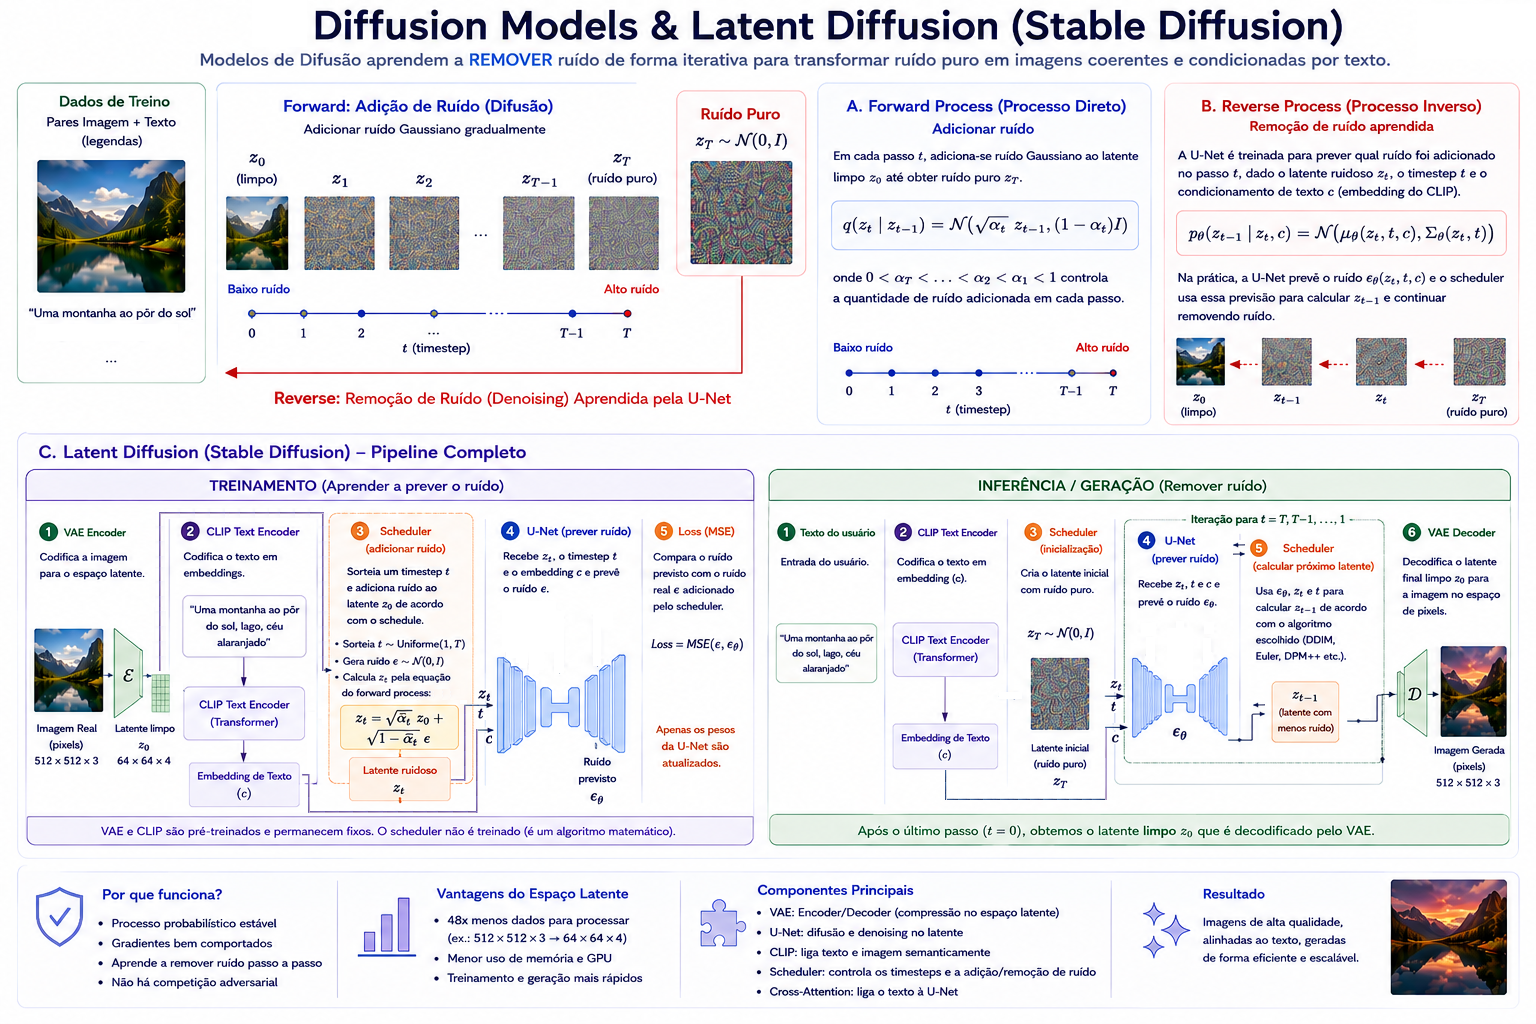

Modelos de difusão utilizam VAEs porque eles estruturam os dados em um espaço latente contínuo e aproximadamente gaussiano, compatível com o ruído gaussiano empregado pelo processo de difusão. Essa característica torna a geração mais estável, facilita a amostragem e melhora a capacidade de generalização do modelo.

#### U-Net e CLIP

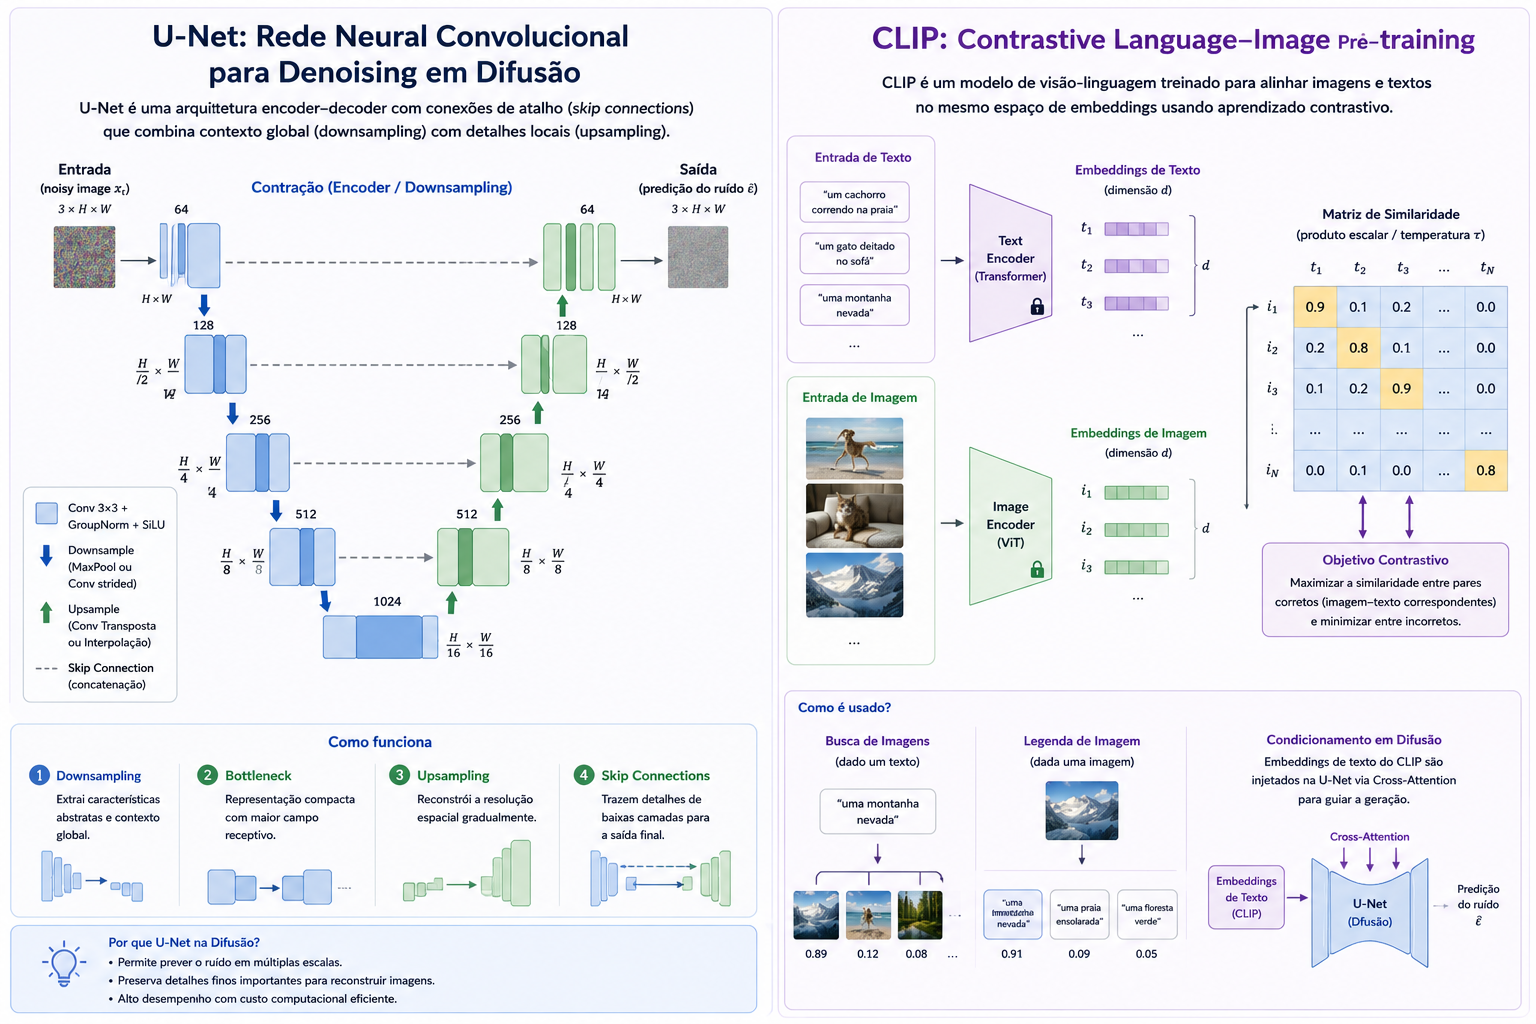

## ⚡ Estratégia de Execução para Aula

A partir desta etapa usamos **Stable Diffusion v1.5**. O custo computacional cresce quase linearmente com o número de passos de denoising e fortemente com a resolução.

**O notebook em `FAST_MODE=True`**: menor resolução, poucos passos por demonstração e menos repetições. Isso preserva os conceitos de prompt, CFG, denoising e semente fixa, mas reduz bastante o tempo de execução.

> **Ponto importante:** `attention_slicing` economiza VRAM, mas em GPUs com memória suficiente costuma **deixar a inferência mais lenta**. Por isso ele só é ativado automaticamente quando a GPU tem pouca VRAM.

Para uma execução mais pesada, altere `FAST_MODE=False` na Etapa 1.


### 3. Carregamento Otimizado do Pipeline Stable Diffusion v1.5

In [ ]:
model_id = 'runwayml/stable-diffusion-v1-5'

# fp16 reduz memória e acelera a inferência em GPUs NVIDIA compatíveis.
# use_safetensors=True evita checkpoints legados quando disponíveis.
load_kwargs = {
    'torch_dtype': torch.float16 if torch.cuda.is_available() else torch.float32,
    'safety_checker': None,
}
if torch.cuda.is_available():
    load_kwargs['use_safetensors'] = True

# TODO Crie o Pipeline chamando StableDiffusionPipeline para carregar o modelo
# pré-treinado "runwayml/stable-diffusion-v1-5" por meio do
# método from_pretrained, passando model_id e **load_kwargs.
pipe = ...

# Vamos usar DPMSolverMultistepScheduler no lugar do scheduler padrão
# DPM (Diffusion Probabilistic Model) é a família de modelos utilizada pelo Stable Diffusion.
# O DPM-Solver Multistep permite utilizar múltiplos passos para acelerar a
# inferência mantendo boa qualidade nas imagens geradas.
# TODO Configure o scheduler utilizando DPMSolverMultistepScheduler.from_config
# e passando pipe.scheduler.config como parâmetro.
pipe.scheduler = ...

# TODO Mova o pipeline para o dispositivo de execução (CPU ou GPU).
# Quando uma GPU está disponível, a geração de imagens torna-se
# significativamente mais rápida.
pipe = ...

In [ ]:
# IMPORTANTE: attention slicing economiza VRAM, mas normalmente REDUZ a velocidade.
# Portanto, não ativamos por padrão em GPUs adequadas para a aula.
if torch.cuda.is_available():
    vram_gb = torch.cuda.get_device_properties(0).total_memory / (1024 ** 3)
    if vram_gb < 6:
        print('[INFO] GPU com pouca VRAM: ativando attention slicing como fallback.')
        pipe.enable_attention_slicing()
    else:
        print('[INFO] GPU com VRAM suficiente: attention slicing DESATIVADO para priorizar velocidade.')

# Pequena otimização estrutural para GPUs NVIDIA.
if torch.cuda.is_available():
    try:
        pipe.unet.to(memory_format=torch.channels_last)
        pipe.vae.to(memory_format=torch.channels_last)
        print('[INFO] channels_last ativado para UNet/VAE.')
    except Exception as e:
        print(f'[INFO] channels_last não aplicado: {e}')

pipe.set_progress_bar_config(disable=False)

if torch.cuda.is_available():
    mem_alloc = torch.cuda.memory_allocated(0) / (1024 ** 3)
    mem_res = torch.cuda.memory_reserved(0) / (1024 ** 3)
    print(f'[INFO] VRAM alocada: {mem_alloc:.2f} GB | reservada: {mem_res:.2f} GB')

### 4. Geração Inicial de Imagem

In [ ]:
prompt = ...

In [ ]:
generator = torch.Generator(device=device).manual_seed(RANDOM_SEED)

print(f'[INFO] Gerando em {IMAGE_SIZE}x{IMAGE_SIZE} com {INITIAL_STEPS} passos...')


In [ ]:
start_gen = time.time()

# TODO Execute o pipeline de geração de imagens armazenado em pipe.
# Utilize as variáveis prompt, INITIAL_STEPS, IMAGE_SIZE e generator
# para preencher os parâmetros prompt, num_inference_steps, width,
# height e generator. Coloque guidance_scale=7.5
with torch.inference_mode():
    with torch.autocast('cuda', dtype=torch.float16) if torch.cuda.is_available() else torch.no_grad():
        result = ...

# TODO Acesse a lista de imagens retornada em result.images
# e armazene a primeira imagem na variável image.
image = ...

if torch.cuda.is_available():
    torch.cuda.synchronize()
gen_time = time.time() - start_gen
print(f'[INFO] Imagem gerada em {gen_time:.2f} segundos.')

In [ ]:
plt.figure(figsize=(6, 6))
plt.imshow(image)
plt.title(f'Prompt: "{prompt[:45]}..."\n{IMAGE_SIZE}x{IMAGE_SIZE} | Passos: {INITIAL_STEPS} | CFG: 7.5 | {gen_time:.2f}s', fontsize=10)
plt.axis('off')
plt.tight_layout()
plt.show()


* O modelo combina os elementos semânticos descritos no prompt em uma composição visual coerente.
* O condicionamento por texto orienta a trajetória de *denoising* no espaço latente, permitindo geração de imagens sem necessidade de retreinamento do modelo.


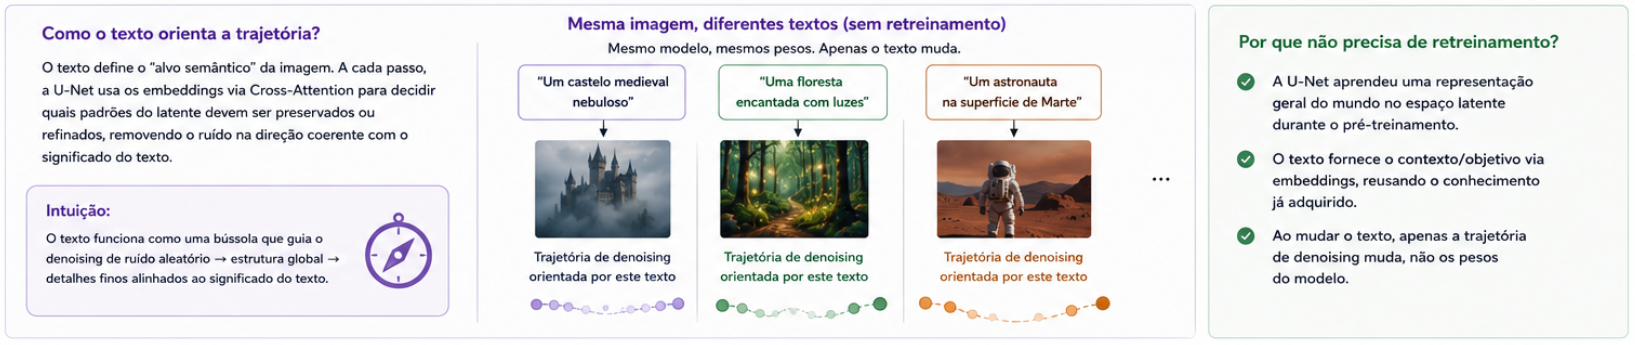

## 5. Experimentos com a Escala de Orientação (CFG Scale)

## 🎛️ Manipulação de Parâmetros de Controle em Inferência

Para controlar rigorosamente o comportamento da geração, manipulamos quatro parâmetros principais:

1. **`prompt`:** Descrição positiva das características semânticas, estilos e objetos desejados.
2. **`negative_prompt`:** Especifica o que o modelo deve **evitar** ou atenuar na geração (ex: *"blurry, low quality, distorted hands, extra limbs"*).
3. **`num_inference_steps`:** Número de passos discretos no processo de difusão reversa ($t_T \to t_0$). Mais passos melhoram o detalhamento até atingir um ponto de saturação.
4. **`guidance_scale` (CFG Scale - Classifier-Free Guidance):** Controla o quão fortemente a geração deve aderir ao prompt textual vs. manter liberdade artística estocástica.

Formulação matemática do CFG:
$$
\epsilon_{\text{pred}} = \epsilon_{\text{uncond}} + w \cdot \left(\epsilon_{\text{cond}} - \epsilon_{\text{uncond}}\right)
$$

Onde $w$ é a `guidance_scale`:
* $w = 0 \text{ ou } 1$: O modelo quase ignora a descrição textual (geração quase incondicional).
* $w \in [7, 8]$: Equilíbrio ideal entre fidelidade ao texto e qualidade estética natural.
* $w > 15$: Força exagerada em direção ao prompt, frequentemente causando saturação excessiva de cores e artefatos visuais.

In [ ]:
cfg_prompt = ...

In [ ]:
cfg_scales = [1.0, 7.5, 15.0] if FAST_MODE else [1.0, 7.0, 15.0, 30.0]

In [ ]:
cfg_images = []

# TODO Execute o pipeline de geração de imagens armazenado em pipe.
# Utilize as variáveis cfg_prompt, CFG_STEPS, IMAGE_SIZE, gen e cfg
# para preencher os parâmetros prompt, num_inference_steps, width,
# height, generator e guidance_scale
for cfg in cfg_scales:
    gen = torch.Generator(device=device).manual_seed(RANDOM_SEED)
    with torch.inference_mode():
        with torch.autocast('cuda', dtype=torch.float16) if torch.cuda.is_available() else torch.no_grad():
            pipe_result = ...

            # TODO Acesse a lista de imagens retornada em pipe_result.images
            # e armazene a primeira imagem na variável image.
            img = ...

    # TODO adicione na lista cfg_images a imagem img acima
    cfg_images.append(...)

In [ ]:
fig, axes = plt.subplots(1, len(cfg_scales), figsize=(5 * len(cfg_scales), 5))
axes = np.atleast_1d(axes)
for idx, (cfg, img) in enumerate(zip(cfg_scales, cfg_images)):
    axes[idx].imshow(img)
    #status = 'Sem orientação' if cfg == 1.0 else 'Padrão' if cfg == 7.5 else 'Alta orientação'
    status = ' (Sem Orientação)' if cfg == 1.0 else ' (Padrão Ideal)' if cfg == 7.0 else ' (Alta Orientação)' if cfg == 15.0 else ' (Saturado/Artefatos)'
    axes[idx].set_title(f'CFG: {cfg} — {status}', fontsize=10, fontweight='bold')
    axes[idx].axis('off')

plt.suptitle('Impacto da CFG Scale na Aderência ao Prompt', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 📊 Interpretação da Grade Comparativa do CFG Scale

* **Como interpretar:**
  * **CFG = 1.0:** pouca orientação pelo texto; a geração preserva maior liberdade estocástica.
  * **CFG = 7.5:** forte aderência ao prompt com boa qualidade visual.
  * **CFG = 15.0:** a orientação é mais intensa e pode aumentar saturação, contraste e artefatos dependendo do prompt.
* **Quais conclusões podem ser tiradas:** O CFG controla a força com que a trajetória de *denoising* é direcionada pelo condicionamento textual. Valores moderados normalmente são um bom ponto de partida.


## 6. Experimento com exemplo negativo

## 💭 Como o Negative Prompt altera matematicamente o direcionamento do vetor no espaço latente?

### Resposta e Explicação Vetorial:
Quando informamos um `negative_prompt`, a equação do Classifier-Free Guidance é expandida. Em vez de estimar o ruído incondicional $\epsilon_{\text{uncond}}$ usando uma string vazia `""`, o modelo calcula o vetor de condicionamento negativo $\epsilon_{\text{neg}}$:

$$
\epsilon_{\text{pred}} = \epsilon_{\text{neg}} + w \cdot \left(\epsilon_{\text{pos}} - \epsilon_{\text{neg}}\right)
$$

Ao subtrair o vetor de ruído associado ao `negative_prompt` ($\epsilon_{\text{neg}}$) do vetor condicional positivo ($\epsilon_{\text{pos}}$), calculamos um **vetor de deslocamento no espaço latente**. Esse vetor aponta na direção oposta às características indesejadas, "empurrando" a trajetória de denoising para longe dos conceitos especificados no Negative Prompt.

In [ ]:
neg_prompt = ...

In [ ]:
cfg_images = []

# TODO Execute o pipeline de geração de imagens armazenado em pipe.
# Utilize as variáveis cfg_prompt, CFG_STEPS, IMAGE_SIZE, gen e cfg
# para preencher os parâmetros prompt, num_inference_steps, width,
# height, generator e guidance_scale. Adicione aogra negative_prompt=neg_prompt
for cfg in cfg_scales:
    gen = torch.Generator(device=device).manual_seed(RANDOM_SEED)
    with torch.inference_mode():
        with torch.autocast('cuda', dtype=torch.float16) if torch.cuda.is_available() else torch.no_grad():
            pipe_result = ...

            # TODO Acesse a lista de imagens retornada em pipe_result.images
            # e armazene a primeira imagem na variável image.
            img = ...

    # TODO adicione na lista cfg_images a imagem img acima
    cfg_images.append(...)

In [ ]:
fig, axes = plt.subplots(1, len(cfg_scales), figsize=(5 * len(cfg_scales), 5))
axes = np.atleast_1d(axes)
for idx, (cfg, img) in enumerate(zip(cfg_scales, cfg_images)):
    axes[idx].imshow(img)
    status = ' (Sem Orientação)' if cfg == 1.0 else ' (Padrão Ideal)' if cfg == 7.0 else ' (Alta Orientação)' if cfg == 15.0 else ' (Saturado/Artefatos)'
    axes[idx].set_title(f'CFG: {cfg} — {status}', fontsize=10, fontweight='bold')
    axes[idx].axis('off')

plt.suptitle('Impacto da CFG Scale na Aderência ao Prompt', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 7. Extração e Visualização dos Estados Latentes Intermediários

Uma das maiores vantagens didáticas dos modelos de difusão é observar a **emergência progressiva da estrutura** a partir do ruído.

Durante o loop de inferência da U-Net, o tensor latente $z_t$ transita do estado inicial ruidoso até o estado final. Ao capturar alguns passos intermediários e passar $z_t$ pelo **Decoder do VAE**, podemos pré-visualizar a imagem em formação.


In [ ]:
denoise_prompt = ...

In [ ]:
total_steps = LATENT_STEPS
# Menos checkpoints reduzem o custo de decodificação do VAE.
target_steps = [1, 4, 8, total_steps] if FAST_MODE else [1, 5, 10, 15, 23, 30]
latents_history = {}

def latents_callback(pipe, step, timestep, callback_kwargs):
    # O callback_on_step_end recebe o latente já atualizado neste passo.
    current_step = step + 1
    if current_step in target_steps:
        latents_history[current_step] = callback_kwargs['latents'].detach().cpu()
    return callback_kwargs

gen = torch.Generator(device=device).manual_seed(RANDOM_SEED)
print(f'[INFO] Denoising em {total_steps} passos; capturando {target_steps}.')

In [ ]:
# TODO Execute o pipeline de geração de imagens armazenado em pipe.
# Utilize as variáveis denoise_prompt, total_steps, IMAGE_SIZE e gen
# para preencher os parâmetros prompt, num_inference_steps, width,
# height e generator. Utilize também a função latents_callback
# no parâmetro callback_on_step_end e ['latents'] em
# callback_on_step_end_tensor_inputs
with torch.inference_mode():
    with torch.autocast('cuda', dtype=torch.float16) if torch.cuda.is_available() else torch.no_grad():
        pipe_result = ...

In [ ]:
# Decodificação dos poucos checkpoints armazenados.
decoded_previews = {}
scaling_factor = pipe.vae.config.scaling_factor

for step_num, lat_cpu in latents_history.items():
    lat = lat_cpu.to(device=device, dtype=pipe.vae.dtype)
    with torch.inference_mode():
        decoded_tensor = pipe.vae.decode(lat / scaling_factor).sample
        decoded_tensor = (decoded_tensor / 2 + 0.5).clamp(0, 1)
        decoded_img = decoded_tensor.float().cpu().permute(0, 2, 3, 1).numpy()[0]
        decoded_previews[step_num] = decoded_img

fig, axes = plt.subplots(1, len(target_steps), figsize=(4 * len(target_steps), 4))
axes = np.atleast_1d(axes)
for idx, step_num in enumerate(target_steps):
    if step_num in decoded_previews:
        axes[idx].imshow(decoded_previews[step_num])
        if step_num == 1:
            stage_name = 'Ruído'
        elif step_num <= total_steps * 0.35:
            stage_name = 'Estrutura inicial'
        elif step_num < total_steps:
            stage_name = 'Refinamento'
        else:
            stage_name = 'Resultado final'
        axes[idx].set_title(f'Passo {step_num}/{total_steps}\n{stage_name}', fontsize=10, fontweight='bold')
    axes[idx].axis('off')

plt.suptitle('Reconstrução Progressiva da Imagem no Espaço Latente', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


### 📊 Interpretação da Reconstrução no Espaço Latente

* **O que está sendo mostrado:** Quatro estados intermediários do latente capturados nos passos `1`, `4`, `8` e no passo final.
* **Como interpretar:**
  * **Passo 1:** ainda há grande influência do ruído.
  * **Passos intermediários:** estruturas globais, cores e composição começam a ficar mais definidas.
  * **Passo final:** detalhes e refinamentos estão incorporados à imagem.
* **Quais conclusões podem ser tiradas:** A geração acontece iterativamente: o modelo parte de um estado altamente ruidoso e, passo a passo, organiza a informação até chegar à imagem final.


## 8. Experimento sobre Trade-off entre Passos de Inferência e Tempo

In [ ]:
ex1_prompt = 'A cute robot reading an ancient leather book in a cozy library, warm lighting, 8k'

In [ ]:
steps_list = EX1_STEPS
ex1_images = []
ex1_times = []

print(f'[INFO] Exercício 1: {steps_list}')
print('[INFO] Em GPUs lentas, use somente [4, 10, 20].')

for steps in steps_list:
    gen = torch.Generator(device=device).manual_seed(RANDOM_SEED)
    if torch.cuda.is_available():
        torch.cuda.synchronize()
    t_start = time.time()

    with torch.inference_mode():
        with torch.autocast('cuda', dtype=torch.float16) if torch.cuda.is_available() else torch.no_grad():
            img = pipe(
                prompt=ex1_prompt,
                num_inference_steps=steps,
                guidance_scale=7.5,
                width=IMAGE_SIZE,
                height=IMAGE_SIZE,
                generator=gen,
            ).images[0]

    if torch.cuda.is_available():
        torch.cuda.synchronize()
    t_elapsed = time.time() - t_start
    ex1_images.append(img)
    ex1_times.append(t_elapsed)
    print(f' -> {steps} passos | {t_elapsed:.2f} s')

fig, axes = plt.subplots(1, len(steps_list), figsize=(6 * len(steps_list), 5))
axes = np.atleast_1d(axes)
for idx, (steps, img, duration) in enumerate(zip(steps_list, ex1_images, ex1_times)):
    axes[idx].imshow(img)
    axes[idx].set_title(f'Passos: {steps}\nTempo: {duration:.2f}s', fontsize=10, fontweight='bold')
    axes[idx].axis('off')

plt.suptitle('Exercício 1: Trade-off entre Passos, Tempo e Qualidade', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


* **Poucos passos:** geração muito rápida, mas com maior chance de aparência incompleta ou perda de detalhes.
* **Número intermediário:** costuma oferecer um bom equilíbrio entre tempo e qualidade.
* **Mais passos:** aumenta o custo computacional; o ganho visual tende a diminuir depois de certo ponto.


## 9. Resumo dos Principais Conceitos

| Conceito / Modelo | Generative Adversarial Networks (GANs) | Diffusion Models (Stable Diffusion) |
| :--- | :--- | :--- |
| **Paradigmas** | Jogo de Soma Zero Minimax ($G$ vs. $D$) | Denoising Probabilístico Iterativo (U-Net) |
| **Estabilidade de Treinamento** | Frágil (risco de *Mode Collapse* e gradiente evanescente) | Alta (otimização por erro de previsão do ruído) |
| **Velocidade de Inferência** | Extremamente rápida (um *forward pass* em $G$) | Mais lenta porque requer múltiplos passos iterativos |
| **Qualidade e Diversidade** | Alta fidelidade, porém com desafios de diversidade e estabilidade | Alta qualidade e boa cobertura da distribuição |
| **Espaço de Operação** | Pode operar diretamente em pixels ou espaço latente | Stable Diffusion opera no espaço latente de um VAE |

---

# 10. Conclusão

Nesta aula, avançamos para o estado da arte em geração multimodal de alta fidelidade:

* **GAN (DCGAN) — O Ponto de Partida:** Introduz a IA Generativa via competição adversarial, sendo ultra-rápida, porém sujeita a instabilidades e *mode collapse*.
* **Modelos de Difusão (Stable Diffusion) — O Estado da Arte:** Consolidam a IA Generativa atual ao substituir a competição instável das GANs por um processo estatístico controlado de remoção de ruído (*denoising*) passo a passo, orientado por mecanismos de atenção (*Attention*) e embeddings de texto (*CLIP*).

Essa abordagem garante maior estabilidade de treinamento, cobertura completa da distribuição dos dados e geração precisa a partir de comandos em linguagem natural.
